# **Non-Linear regression**

Marek Šugár

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# ML Stuff
from sklearn.linear_model import LinearRegression

In [2]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

# **Non-linear regression**

a.k.a. plain and simple :)

In [4]:
performance_tracker = {}
performance_simple = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 4 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_simple[ticker] = []

    MAPEs = []
    AccuracyToSimple = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()
        poly = PolynomialFeatures(degree=2)

        Training_Features = poly.fit_transform(scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length]))
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = poly.transform(scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length]))
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = LinearRegression()

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)

        print(ticker)
        
        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        AccuracyToSimple.append(mean_absolute_percentage_error(Test_Target, prediction) <= (mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]])))
    performance_simple[ticker] = AccuracyToSimple.copy()
    performance_tracker[ticker] = MAPEs.copy()

ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN
ACN


KeyboardInterrupt: 

In [9]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [10]:
np.mean(list(mean_performances.values()))

np.float64(2.188632164108597)

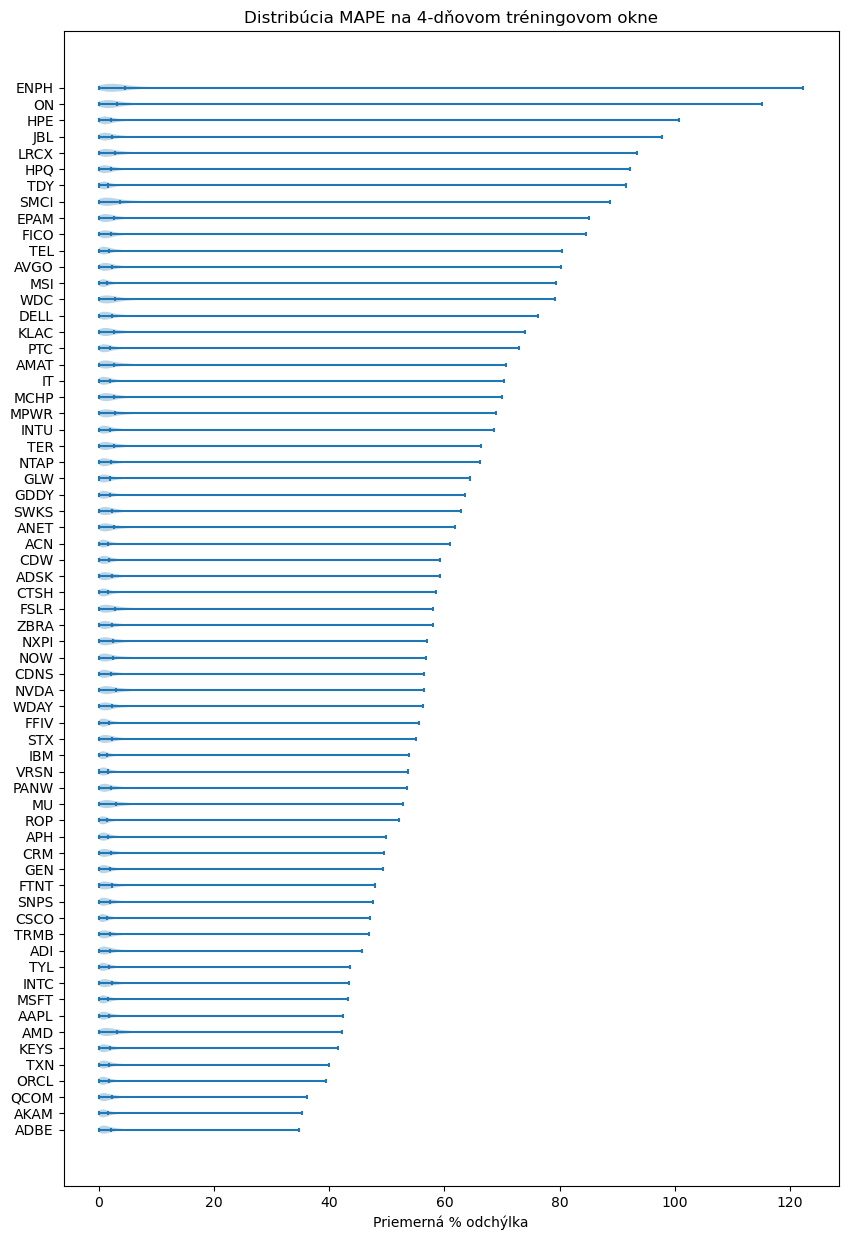

In [11]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()

In [12]:
mean_performances

{'ROP': np.float64(1.4015054193110486),
 'IBM': np.float64(1.4485892637781903),
 'CSCO': np.float64(1.462414834330574),
 'MSI': np.float64(1.4740069534683298),
 'VRSN': np.float64(1.5501863970135688),
 'ACN': np.float64(1.5996695387611097),
 'TDY': np.float64(1.6193391911741142),
 'APH': np.float64(1.6245374063126663),
 'CTSH': np.float64(1.62974596901741),
 'MSFT': np.float64(1.6451333111861763),
 'AKAM': np.float64(1.6483011908904341),
 'ORCL': np.float64(1.6940561925165192),
 'TYL': np.float64(1.7126331204012744),
 'FFIV': np.float64(1.7412919833505918),
 'TEL': np.float64(1.7601869467518394),
 'AAPL': np.float64(1.7839575763517417),
 'CDW': np.float64(1.8013729103547307),
 'TXN': np.float64(1.821633340935932),
 'GLW': np.float64(1.8468633435358492),
 'IT': np.float64(1.8479432710662589),
 'GEN': np.float64(1.853298454653603),
 'KEYS': np.float64(1.862748776464907),
 'GDDY': np.float64(1.893459290591015),
 'SNPS': np.float64(1.9624290181373445),
 'PTC': np.float64(1.9734096631066405

In [13]:
np.mean([np.mean(i) for i in performance_simple.values()])

np.float64(0.40260390585878814)